In [9]:
!pip install deepface opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.0 MB/s eta 0:00:00


In [1]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [4]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Capture Image';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getVideoTracks()[0].stop();
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


In [7]:
photo_path = take_photo()
print("Image captured and saved as:", photo_path)

<IPython.core.display.Javascript object>

Image captured and saved as: photo.jpg


26-09-02 04:39:36 - Directory /root/.deepface has been created
26-09-02 04:39:36 - Directory /root/.deepface/weights has been created


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5


26-09-02 04:39:37 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


100%|██████████| 5.98M/5.98M [00:00<00:00, 112MB/s]


Detected Emotion: angry


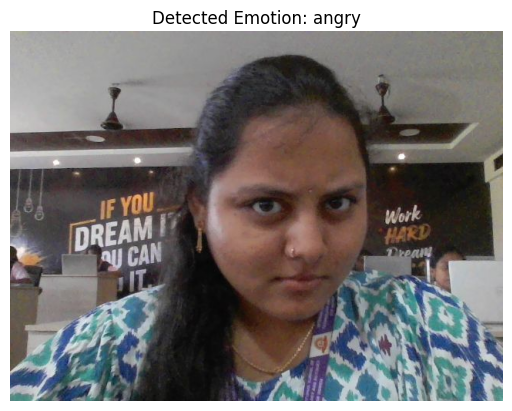

In [10]:
from deepface import DeepFace

# Read image
img = cv2.imread(photo_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Analyze emotion
result = DeepFace.analyze(
    img,
    actions=['emotion'],
    enforce_detection=False
)

emotion = result[0]['dominant_emotion']

# Display result
plt.imshow(img)
plt.title(f"Detected Emotion: {emotion}")
plt.axis('off')

print("Detected Emotion:", emotion)


In [15]:
photo_path = take_photo()
print("Image captured and saved as:", photo_path)

<IPython.core.display.Javascript object>

Image captured and saved as: photo.jpg


Detected Emotion: surprise


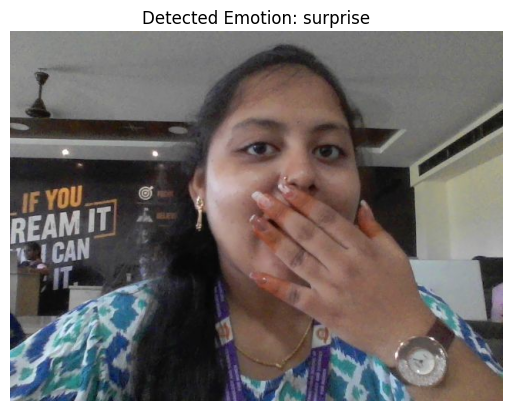

In [16]:
from deepface import DeepFace

# Read image
img = cv2.imread(photo_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Analyze emotion
result = DeepFace.analyze(
    img,
    actions=['emotion'],
    enforce_detection=False
)

emotion = result[0]['dominant_emotion']

# Display result
plt.imshow(img)
plt.title(f"Detected Emotion: {emotion}")
plt.axis('off')

print("Detected Emotion:", emotion)
